In [1]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn

## 0. Data Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [6]:
df = pd.read_csv(Path('../data/ds_salaries.csv'))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [7]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [8]:
def job_family(title):
    
    if 'analyst' in title:
        return 'Data Analyst'
    
    elif 'machine learning' in title or 'ml ' in title or 'mlops' in title or 'ai ' in title:
        return 'ML/AI Engineer'
    
    elif 'data scientist' in title or 'applied scientist' in title or 'research scientist' in title:
        return 'Data Scientist'
    
    elif 'engineer' in title:
        return 'Data Engineer'
    
    elif 'manager' in title or 'head' in title or 'director' in title or 'lead' in title:
        return 'Manager / Leadership'
    
    elif 'architect' in title:
        return 'Data Architect'
    
    else:
        return 'Other'

df['job_title'] = df['job_title'].str.strip().str.lower()
df['job_family'] = df['job_title'].apply(job_family)

## 1. Visualization

    work_year experience_level     avg_salary
0        2020               EN   57511.608696
1        2020               EX  139944.333333
2        2020               MI   87564.718750
3        2020               SE  137240.500000
4        2021               EN   54905.254545
5        2021               EX  186128.000000
6        2021               MI   82116.934783
7        2021               SE  126085.356164
8        2022               EN   77006.024194
9        2022               EX  188260.292683
10       2022               MI  101305.598338
11       2022               SE  147659.688049
12       2023               EN   95283.966102
13       2023               EX  203705.683333
14       2023               MI  116297.596875
15       2023               SE  159568.928516


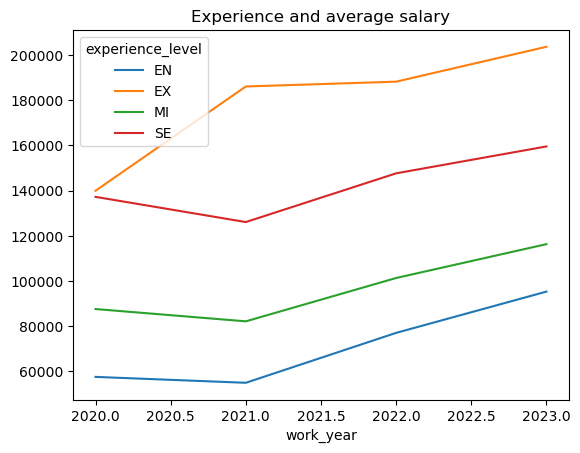

In [9]:
# Q1: Experience and average salary
q1_df = df[['work_year','experience_level','salary_in_usd']].copy()
q1_df = df.groupby(['work_year','experience_level']).agg(
    avg_salary = ('salary_in_usd','mean')
).reset_index()
print(q1_df)
q1_df['work_year'] = q1_df['work_year'].astype(int)
q1_df.pivot(index='work_year', columns='experience_level', values='avg_salary').plot()
plt.title('Experience and average salary')
plt.savefig('q1_exp_vs_avg_salary.png')
plt.show()

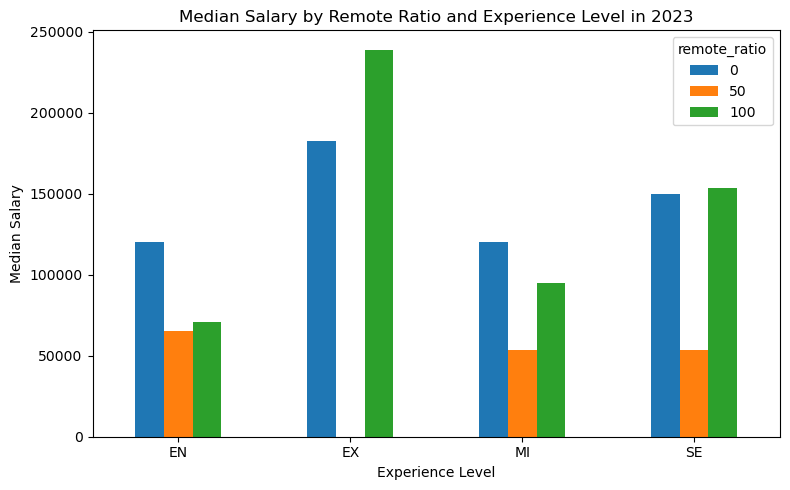

In [10]:
# Q2: Median Salary by Remote Ratio and Experience Level in 2023
q2_df = df[['remote_ratio', 'salary_in_usd', 'experience_level', 'work_year']].copy()

# Construct log salary
q2_df['log_salary'] = np.log(q2_df['salary_in_usd'])

# Only get 2023 data
q2_df = q2_df[q2_df['work_year'] == 2023]

median_salary = q2_df.groupby(
    ['experience_level', 'remote_ratio']
)['salary_in_usd'].median().unstack()

# Get bar chart
median_salary.plot(kind='bar', figsize=(8,5))
plt.title('Median Salary by Remote Ratio and Experience Level in 2023')
plt.ylabel('Median Salary')
plt.xlabel('Experience Level')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('q2_med_salary_vs_remote&exp.png')
plt.show()

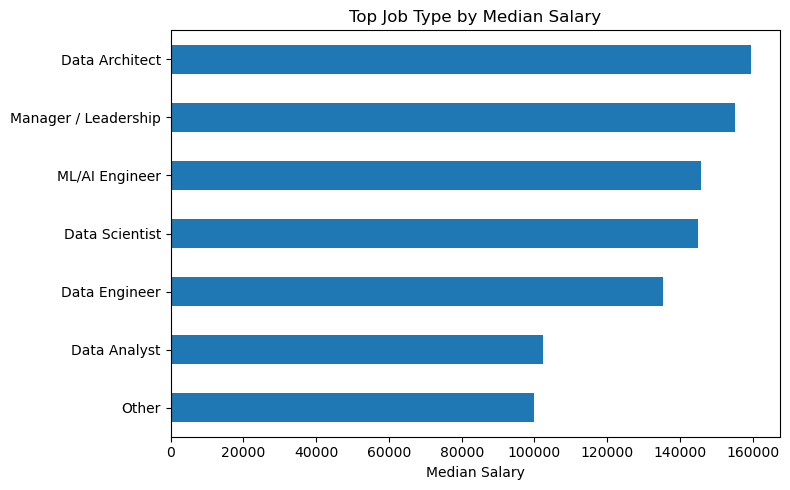

In [11]:
# Q3 part 1: Top Job Type by Median Salary
q3_df = df[['job_family','salary_in_usd','experience_level']].copy()
# print(len(df['job_title']))
valid_family = q3_df['job_family'].value_counts()
valid_family = valid_family[valid_family >= 20].index

q3_df = q3_df[q3_df['job_family'].isin(valid_family)].copy()

# 2. top 10 job_family by median salary
top = (
    q3_df.groupby('job_family')['salary_in_usd']
    .median()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
top.sort_values().plot(kind='barh')
plt.title('Top Job Type by Median Salary')
plt.xlabel('Median Salary')
plt.ylabel('')
plt.tight_layout()
plt.savefig('q3_job_type_vs_med_salary.png')
plt.show()

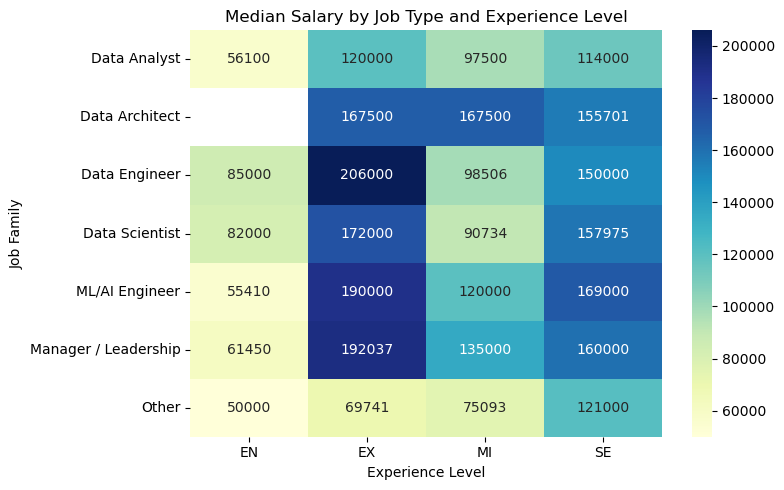

In [12]:
# Q3 part 2: Median Salary by Job Type and Experience Level
heatmap_data = q3_df.pivot_table(
    index='job_family',
    columns='experience_level',
    values='salary_in_usd',
    aggfunc='median'
)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Median Salary by Job Type and Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Job Family')
plt.tight_layout()
plt.savefig('q3_med_salary_vs_job_type&exp.png')
plt.show()

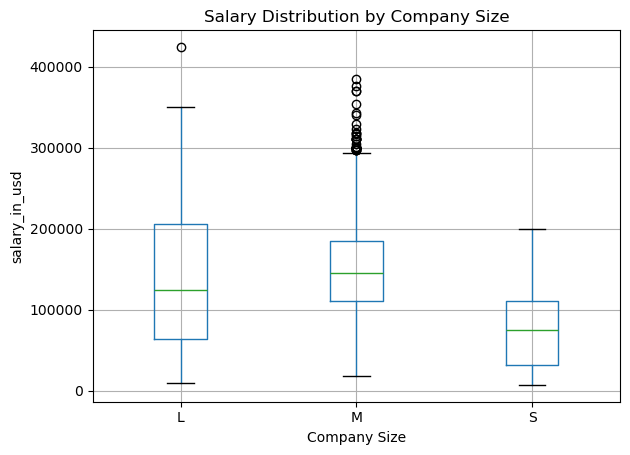

In [13]:
# Q4 part 1: Salary Distribution by Company Size
q4_df = df[['company_size','salary_in_usd','experience_level','job_family','work_year']].copy()

# Latest year, 2023
q4_df = q4_df[q4_df['work_year'] == 2023]

q4_df.boxplot(column='salary_in_usd', by='company_size')

plt.title('Salary Distribution by Company Size')
plt.suptitle('')
plt.xlabel('Company Size')
plt.ylabel('salary_in_usd')
plt.tight_layout()
plt.savefig('q4_salary_vs_comp_size')
plt.show()

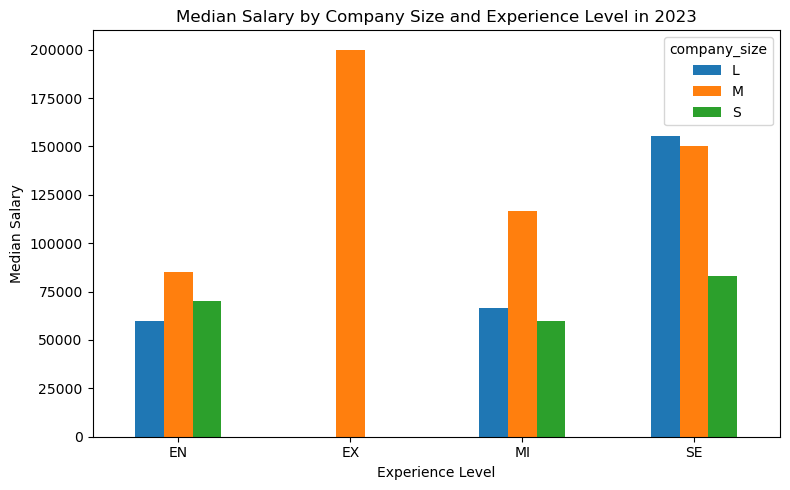

In [14]:
# Q4 part 2: Median Salary by Company Size and Experience Level (2023)
median_salary = q4_df.groupby(
['experience_level','company_size']
)['salary_in_usd'].median().unstack()

median_salary.plot(kind='bar', figsize=(8,5))

plt.title('Median Salary by Company Size and Experience Level in 2023')
plt.ylabel('Median Salary')
plt.xlabel('Experience Level')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('q4_med_salary_vs_comp_size&exp')
plt.show()

        same_country  count  median_salary    mean_salary
0  Different Country     14        56873.5   60744.000000
1       Same Country   1771       145000.0  149743.577075


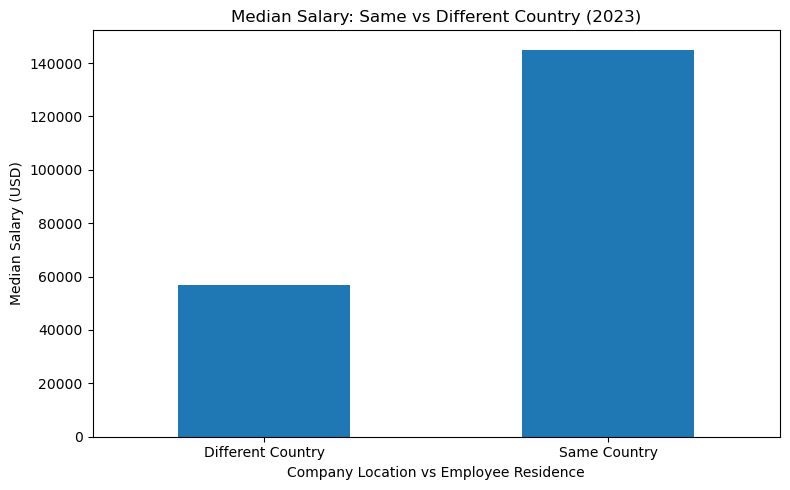

In [15]:
# Q5: Geography-related pattern

# 1. Prepare the data
q5_df = df.copy()
q5_df = q5_df[q5_df['work_year'] == 2023].copy()
q5_df = q5_df.dropna(subset=[
    'salary_in_usd',
    'company_location',
    'employee_residence',
    'remote_ratio'
])
# Create a flag: same country or different country
q5_df['same_country'] = q5_df['company_location'] == q5_df['employee_residence']

# 2. Same country vs different country
same_diff_summary = q5_df.groupby('same_country').agg(
    count=('salary_in_usd', 'count'),
    median_salary=('salary_in_usd', 'median'),
    mean_salary=('salary_in_usd', 'mean')
).reset_index()

same_diff_summary['same_country'] = same_diff_summary['same_country'].map({
    True: 'Same Country',
    False: 'Different Country'
})

print(same_diff_summary)

same_diff_plot = same_diff_summary.set_index('same_country')['median_salary']
ax = same_diff_plot.plot(kind='bar', figsize=(8, 5), rot=0, width=0.5)
ax.set_title('Median Salary: Same vs Different Country (2023)')
ax.set_xlabel('Company Location vs Employee Residence')
ax.set_ylabel('Median Salary (USD)')
plt.tight_layout()
plt.show()

same_country  Different Country  Same Country
remote_ratio                                 
0                       70000.0      145000.0
50                      50000.0       57224.5
100                     60093.0      142500.0


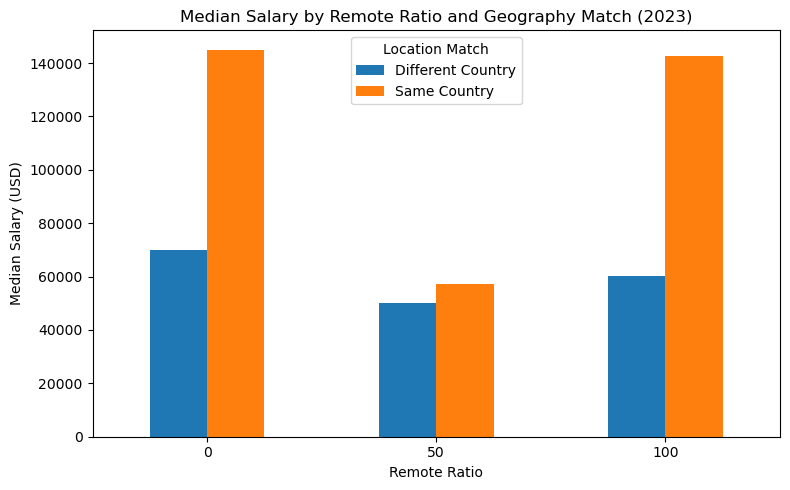

In [16]:
# 3. Same vs different country by remote ratio
same_diff_remote = q5_df.groupby(['remote_ratio', 'same_country']).agg(
    count=('salary_in_usd', 'count'),
    median_salary=('salary_in_usd', 'median')
).reset_index()

same_diff_remote['same_country'] = same_diff_remote['same_country'].map({
    True: 'Same Country',
    False: 'Different Country'
})

remote_pivot = same_diff_remote.pivot(
    index='remote_ratio',
    columns='same_country',
    values='median_salary'
)

print(remote_pivot)

ax = remote_pivot.plot(kind='bar', figsize=(8, 5))
ax.set_title('Median Salary by Remote Ratio and Geography Match (2023)')
ax.set_xlabel('Remote Ratio')
ax.set_ylabel('Median Salary (USD)')
plt.xticks(rotation=0)
plt.legend(title='Location Match')
plt.tight_layout()
plt.show()


  company_location  count  median_salary
5               US   1570       149076.0
0               CA     36       142050.0
1               DE     14        96578.0
3               GB     66        78990.0
2               ES     28        49898.5
4               IN     12        17022.0


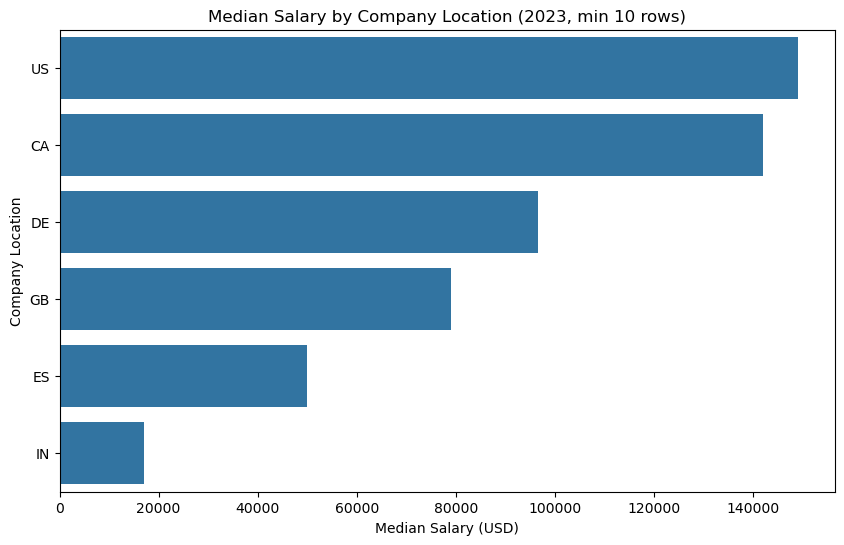

  employee_residence  count  median_salary
5                 US   1565       149500.0
0                 CA     35       143100.0
1                 DE     12       115357.0
3                 GB     66        78990.0
2                 ES     28        49898.5
4                 IN     15        17509.0


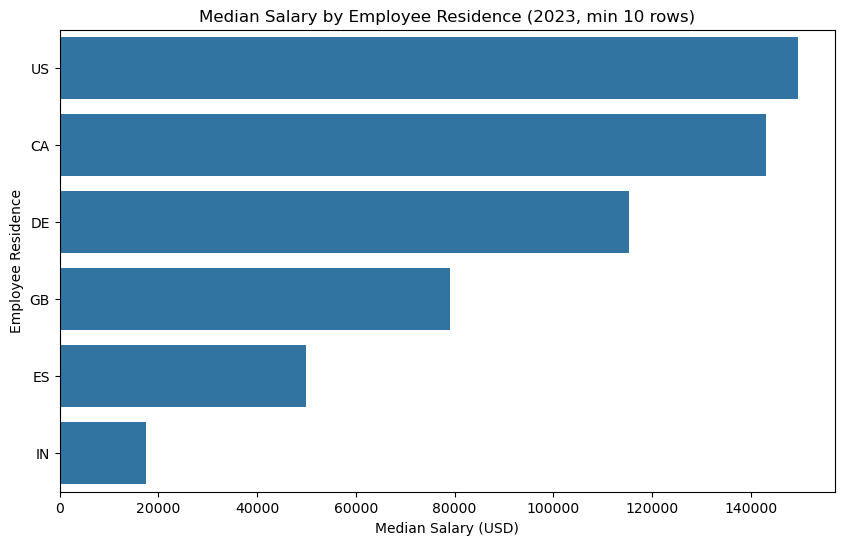

Variation in median salaries by company location:
count         6.000000
mean      88935.750000
std       51557.326304
min       17022.000000
25%       57171.375000
50%       87784.000000
75%      130682.000000
max      149076.000000
Name: median_salary, dtype: float64

Variation in median salaries by employee residence:
count         6.000000
mean      92392.416667
std       52825.734235
min       17509.000000
25%       57171.375000
50%       97173.500000
75%      136164.250000
max      149500.000000
Name: median_salary, dtype: float64


In [17]:
# 4. Company location
company_counts = q5_df['company_location'].value_counts()
valid_company_locations = company_counts[company_counts >= 10].index

company_summary = q5_df[q5_df['company_location'].isin(valid_company_locations)] \
    .groupby('company_location') \
    .agg(
        count=('salary_in_usd', 'count'),
        median_salary=('salary_in_usd', 'median')
    ) \
    .reset_index() \
    .sort_values(by='median_salary', ascending=False)

print(company_summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=company_summary, y='company_location', x='median_salary')
plt.title('Median Salary by Company Location (2023, min 10 rows)')
plt.xlabel('Median Salary (USD)')
plt.ylabel('Company Location')
plt.show()

# 5. Employee residence
residence_counts = q5_df['employee_residence'].value_counts()
valid_residences = residence_counts[residence_counts >= 10].index

residence_summary = q5_df[q5_df['employee_residence'].isin(valid_residences)] \
    .groupby('employee_residence') \
    .agg(
        count=('salary_in_usd', 'count'),
        median_salary=('salary_in_usd', 'median')
    ) \
    .reset_index() \
    .sort_values(by='median_salary', ascending=False)

print(residence_summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=residence_summary, y='employee_residence', x='median_salary')
plt.title('Median Salary by Employee Residence (2023, min 10 rows)')
plt.xlabel('Median Salary (USD)')
plt.ylabel('Employee Residence')
plt.show()

# 6. Compare variation in grouped medians
print("Variation in median salaries by company location:")
print(company_summary['median_salary'].describe())

print("\nVariation in median salaries by employee residence:")
print(residence_summary['median_salary'].describe())

Salary aligns similarly with both company location and employee residence. The country rankings and median salary values are almost the same in both tables, so neither variable appears clearly stronger. However, this may be partly because the dataset is dominated by U.S. observations.

The most important geography-related pattern is not whether salary follows company location more than employee residence, but whether the employee and company are located in the same country. One limitation is that the different-country group is very small. But overall, the analysis suggests that geographic alignment between workers and employers is associated with higher salaries in this dataset.

## 2. Model Prediction

In [28]:
def salary_level(s):
    if s < 60000:
        return 0
    elif s < 120000:
        return 1
    else:
        return 2

# drop those cols for consistancy
df_temp = df.drop(columns=["salary", "salary_currency"])
# enocde salary level
df_temp["salary_level"] = df_temp["salary_in_usd"].apply(salary_level)

In [29]:
df_temp.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_family,salary_level
0,2023,SE,FT,principal data scientist,85847,ES,100,ES,L,Data Scientist,1
1,2023,MI,CT,ml engineer,30000,US,100,US,S,ML/AI Engineer,0
2,2023,MI,CT,ml engineer,25500,US,100,US,S,ML/AI Engineer,0
3,2023,SE,FT,data scientist,175000,CA,100,CA,M,Data Scientist,2
4,2023,SE,FT,data scientist,120000,CA,100,CA,M,Data Scientist,2


### 2.1 Predict Salary Level

In [30]:
X = df_temp.drop(columns=["salary_in_usd", "salary_level"])
y = df_temp["salary_level"]
# encode categorical features
X = pd.get_dummies(X, drop_first=True)

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=143
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Accuracy:", model.score(X_test_scaled, y_test))

Accuracy: 0.7376830892143809


### 2.2 Evaluate Model

In [43]:
from sklearn.metrics import classification_report
pred = model.predict(X_test_scaled)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.65      0.49      0.56        75
           1       0.54      0.42      0.47       202
           2       0.81      0.91      0.86       474

    accuracy                           0.74       751
   macro avg       0.66      0.61      0.63       751
weighted avg       0.72      0.74      0.72       751



### 2.3 Model Visualization

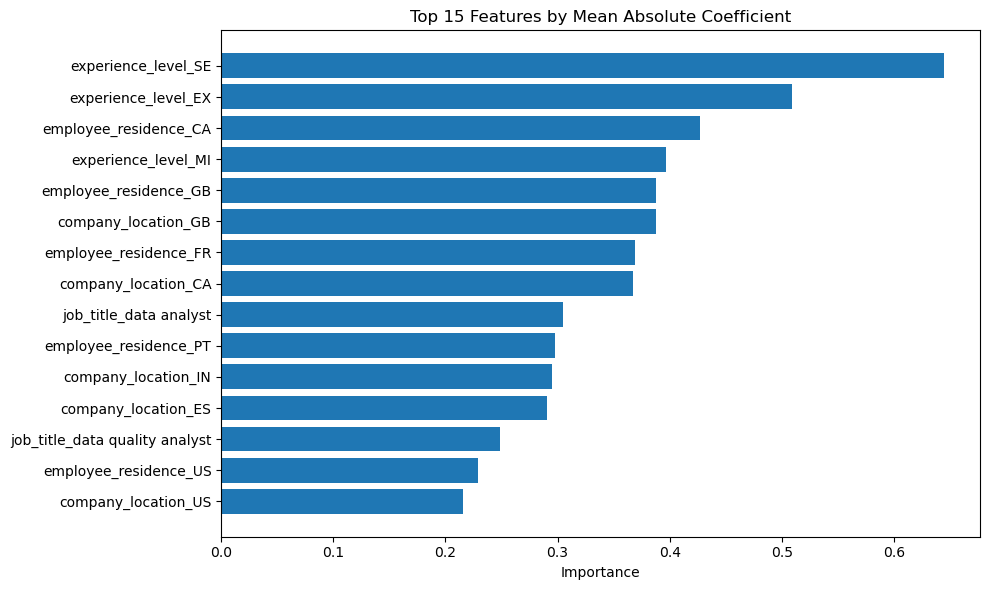

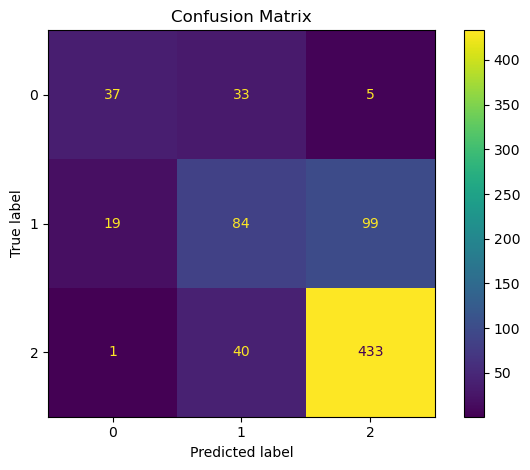

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

# coefficient importance
feature_names = X.columns
coef_df = pd.DataFrame(model.coef_, columns=feature_names, index=model.classes_)

abs_importance = np.abs(model.coef_).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": abs_importance
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"].head(15)[::-1],
         importance_df["importance"].head(15)[::-1])
plt.title("Top 15 Features by Mean Absolute Coefficient")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# confusion matrix
ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### 2.4 Insights from Model Plots

#### (1) Features
From the feature importance ranking above, we can see that the classfication rely heavly on
"experience_level", "company_location" and "employee_residence". This make sense, in more developed countries,
higher experience level usually means higher salary level.

#### (2) Confusion Matrix
From the confusion matrix, we can see that the model performs best at predicting high salary level (class 2), with 433 correct predictions and only 41 misclassifications. This indicates that high-income positions are relatively easier for the model to identify.

For medium salary level (class 1), the model shows moderate performance. For low salary level (class 0), the model has more difficulty. 

Overall, the confusion matrix suggests that the model tends to perform better on higher salary levels, while most classification errors occur between adjacent salary categories, especially between medium and high salary levels.